# Solar Power Generation Prediction using Linear Regression

## Use Case
This project predicts AC power output from a solar plant using operational data such as DC power, daily yield, and time of day.

The goal is to improve energy forecasting and optimize power generation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import joblib

## Data Loading and Exploration

In [ ]:
df = pd.read_csv("/Users/manziivan453icloud.com/Downloads/Projects/linear_regression_model/summative/linear_regression/Plant_1_Generation_Data.csv")
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [ ]:
print("Dataset info:")
df.info()
print("\nBasic statistics:")
df.describe()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB

Basic statistics:


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06


In [ ]:
# Remove night-time data (no solar production)
df = df[df['DC_POWER'] > 0]

## Feature Engineering

In [ ]:
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df['hour'] = df['DATE_TIME'].dt.hour

/tmp/ipykernel_1559/4064872231.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])


## Data Visualization

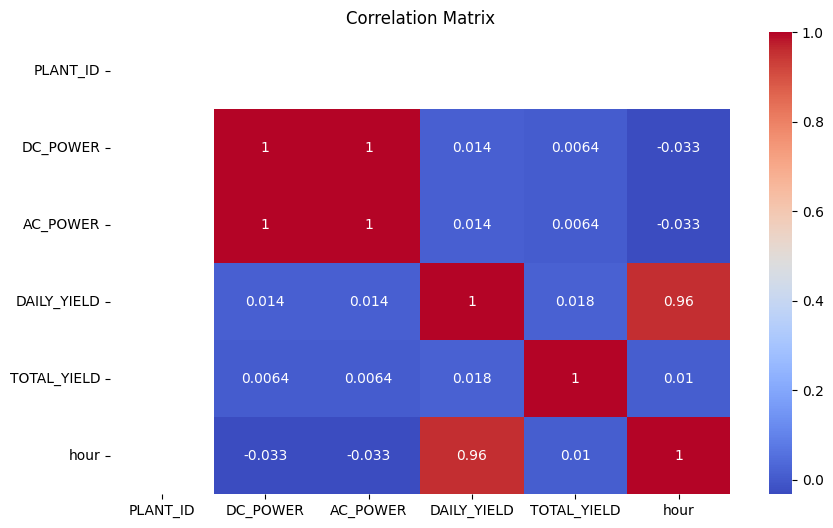

In [ ]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Interpretation

- DC_POWER has a strong positive relationship with AC_POWER
- DAILY_YIELD also contributes to AC_POWER
- Time (hour) influences generation patterns

This shows solar energy depends on system output and time of day.

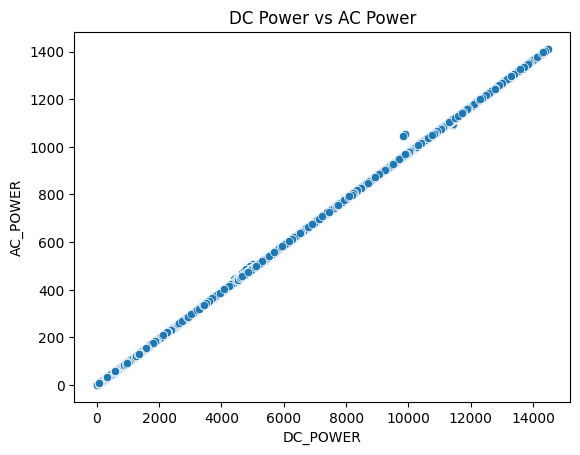

In [ ]:
plt.figure()
sns.scatterplot(x=df['DC_POWER'], y=df['AC_POWER'])
plt.title("DC Power vs AC Power")
plt.show()

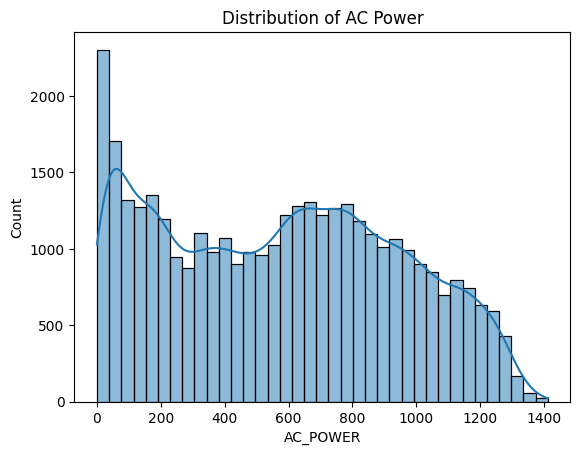

In [ ]:
plt.figure()
sns.histplot(df['AC_POWER'], kde=True)
plt.title("Distribution of AC Power")
plt.show()

## Feature Selection

In [ ]:
features = ['DC_POWER', 'DAILY_YIELD', 'hour']
X = df[features]
y = df['AC_POWER']

## Train-Test Split and Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = rmse

results

{'Linear Regression': np.float64(1.1845065076613022),
 'Decision Tree': np.float64(0.6369985717031464),
 'Random Forest': np.float64(0.5426368329864609)}

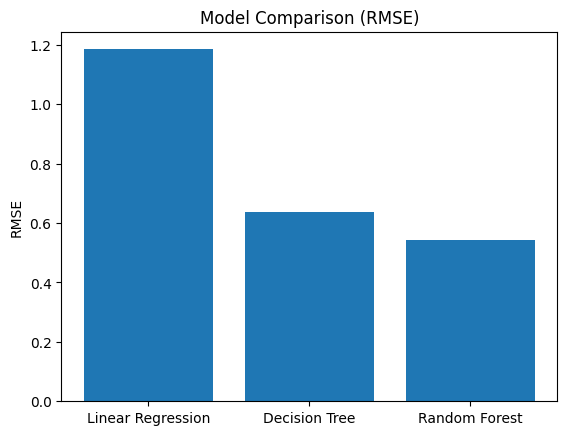

In [ ]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

## Gradient Descent and Loss Curve

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

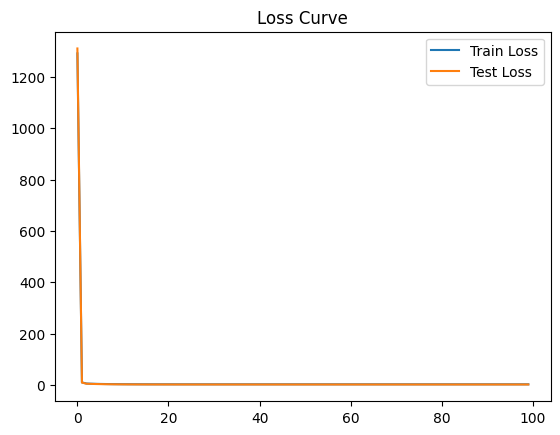

In [ ]:
train_losses = []
test_losses = []

sgd = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.0001, warm_start=True)

for i in range(100):
    sgd.fit(X_train_scaled, y_train)

    y_train_pred = sgd.predict(X_train_scaled)
    y_test_pred = sgd.predict(X_test_scaled)

    train_loss = mean_squared_error(y_train, y_train_pred)
    test_loss = mean_squared_error(y_test, y_test_pred)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

## Linear Regression Visualization

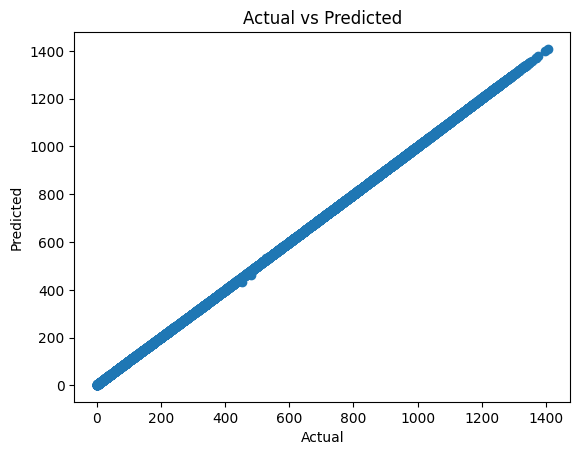

In [ ]:
lr_model = models["Linear Regression"]
y_pred_lr = lr_model.predict(X_test_scaled)

plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## Save Model

In [ ]:
best_model = models[min(results, key=results.get)]

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(features, "features.pkl")

['features.pkl']

## Feature Importance

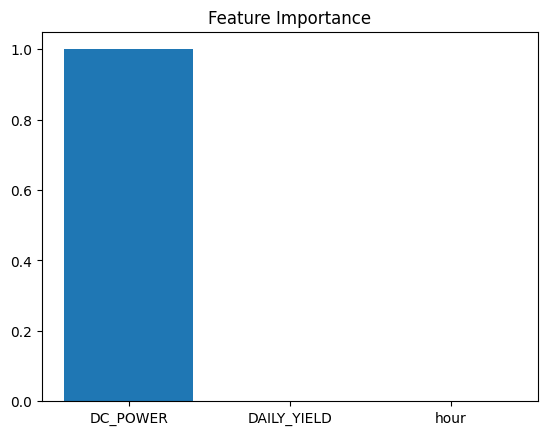

In [ ]:
rf = models["Random Forest"]

importances = rf.feature_importances_

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

## Making Predictions

In [ ]:
loaded_model = joblib.load("best_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

sample_input = X.sample(1).to_dict(orient='records')[0]

input_df = pd.DataFrame([sample_input])
input_scaled = loaded_scaler.transform(input_df)

prediction = loaded_model.predict(input_scaled)

print("Input:", sample_input)
print("Predicted AC Power:", prediction[0])

Input: {'DC_POWER': 4440.285714, 'DAILY_YIELD': 4977.285714, 'hour': 16}
Predicted AC Power: 435.8253750180005


## Summary

- Random Forest performed best
- DC Power is the most important feature
- The model can predict solar power output effectively
- Gradient descent improved optimization